# Plot SPI Raster with Scenic Coordinates

This notebook loads the SPI raster from `processed/spi_index.tif` and overlays scenic point locations from `coords_scenic.txt`.

- Loads the SPI GeoTIFF
- Parses coordinate names and latitude/longitude values
- Reprojects points to the raster CRS
- Displays the SPI map with labeled scenic locations

In [4]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show

# Configure workspace root and paths
cwd = Path.cwd()
if cwd.name == 'spi_gb_north':
    root = cwd
elif (cwd / 'spi_gb_north').exists():
    root = cwd / 'spi_gb_north'
elif (cwd / 'sds' / 'spi_gb_north').exists():
    root = cwd / 'sds' / 'spi_gb_north'
else:
    root = cwd

processed = root / 'data' / 'processed'
outputs = root / 'outputs'
coords_path = root / 'coords_scenic.txt'
spi_output_path = processed / 'spi_index.tif'

outputs.mkdir(parents=True, exist_ok=True)

print(f'root: {root}')
print(f'spi_output_path: {spi_output_path}')
print(f'coords_path: {coords_path}')

if not spi_output_path.exists():
    raise FileNotFoundError(f'SPI raster not found: {spi_output_path}')
if not coords_path.exists():
    raise FileNotFoundError(f'Coordinate file not found: {coords_path}')

root: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north
spi_output_path: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\data\processed\spi_index.tif
coords_path: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\coords_scenic.txt


In [5]:
def parse_coords(file_path):
    pattern = re.compile(r'^(.*?):\s*([0-9.+-]+)°\s*N,\s*([0-9.+-]+)°\s*E', re.IGNORECASE)
    names = []
    lats = []
    lons = []
    for raw in file_path.read_text().splitlines():
        line = raw.strip()
        if not line:
            continue
        match = pattern.match(line)
        if match:
            names.append(match.group(1).strip())
            lats.append(float(match.group(2)))
            lons.append(float(match.group(3)))
        else:
            print(f'WARNING: could not parse line: {line}')
    return names, lats, lons

names, lats, lons = parse_coords(coords_path)
print('Loaded coordinates:')
for name, lat, lon in zip(names, lats, lons):
    print(f'  - {name}: {lat} N, {lon} E')

points_gdf = gpd.GeoDataFrame(
    {'name': names},
    geometry=gpd.points_from_xy(lons, lats),
    crs='EPSG:4326'
)

with rasterio.open(spi_output_path) as src:
    raster_crs = src.crs
    raster_transform = src.transform
    raster_data = src.read(1)
    raster_bounds = src.bounds
    raster_profile = src.profile

print(f'Raster CRS: {raster_crs}')
print(f'Raster bounds: {raster_bounds}')

points_proj = points_gdf.to_crs(raster_crs)
points_proj['x'] = points_proj.geometry.x
points_proj['y'] = points_proj.geometry.y
points_proj

Loaded coordinates:
  - Fairy Meadows: 35.3808 N, 74.5777 E
  - Hunza Valley (Karimabad): 36.3169 N, 74.6499 E
  - Attabad Lake: 36.3369 N, 74.8675 E
  - Deosai National Park: 35.0189 N, 75.4144 E
  - Passu Cones: 36.4788 N, 74.8986 E
  - Khunjerab Pass: 36.8497 N, 75.4573 E
  - Shangrila Lake (Kachura): 35.4262 N, 75.4497 E
Raster CRS: EPSG:32643
Raster bounds: BoundingBox(left=131981.61696435377, bottom=3625639.3237772784, right=744181.6169643537, top=4105739.3237772784)


,name,geometry,x,y
0,Fairy Meadows,POINT (461643.689 3915355.512),461643.689270,3.915356e+06
1,Hunza Valley (Karimabad),POINT (468572.984 4019155.093),468572.984364,4.019155e+06
2,Attabad Lake,POINT (488109.086 4021324.788),488109.086285,4.021325e+06
3,Deosai National Park,POINT (537806.102 3875217.463),537806.102095,3.875217e+06
4,Passu Cones,POINT (490916.62 4037061.279),490916.619936,4.037061e+06
5,Khunjerab Pass,POINT (540768.825 4078296.887),540768.824700,4.078297e+06
6,Shangrila Lake (Kachura),POINT (540822.096 3920401.552),540822.096387,3.920402e+06


Saved figure: c:\Users\AtifA\Desktop\Wasif SDS Project\sds\sds\spi_gb_north\outputs\spi_with_scenic_coords.png


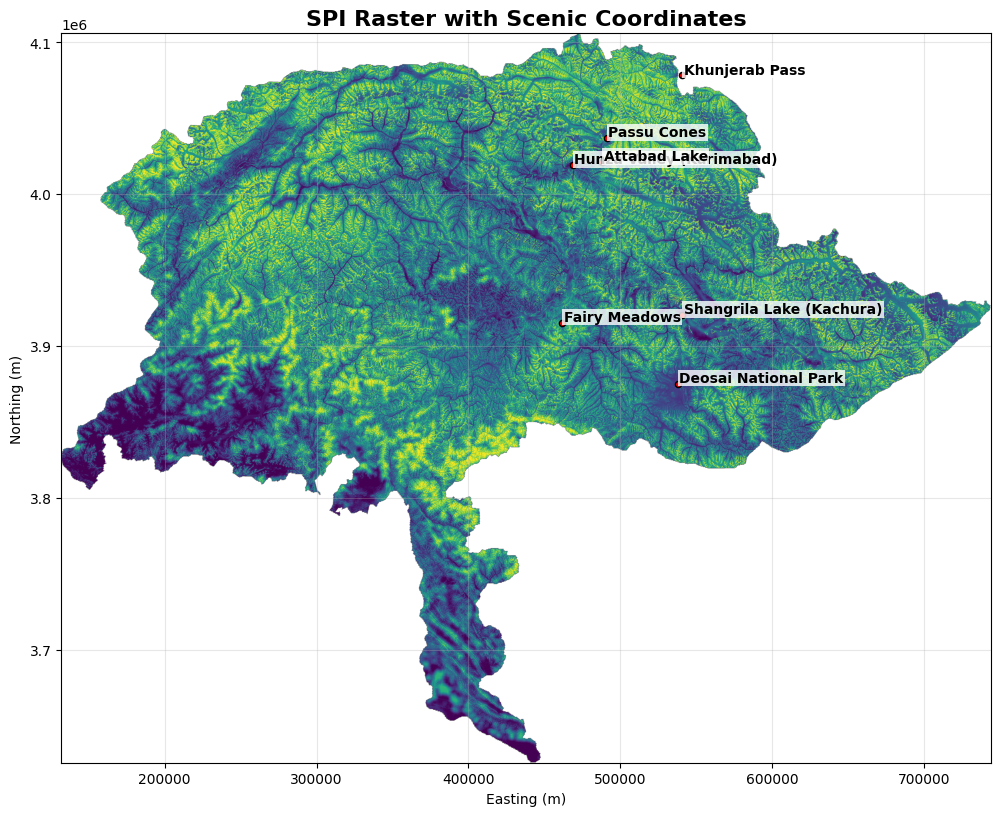

In [7]:
# Plot SPI raster and overlay points
mask = np.isfinite(raster_data)
nodata_value = raster_profile.get('nodata')
if nodata_value is not None:
    mask &= (raster_data != nodata_value)

if not np.any(mask):
    raise ValueError('SPI raster contains no valid pixels to plot')

valid_values = raster_data[mask].astype(np.float32)
vmin = float(np.nanpercentile(valid_values, 2))
vmax = float(np.nanpercentile(valid_values, 98))
if np.isclose(vmin, vmax):
    vmin = float(valid_values.min())
    vmax = float(valid_values.max())
    if np.isclose(vmin, vmax):
        vmin -= 1.0
        vmax += 1.0

plot_data = np.where(mask, raster_data, np.nan).astype(np.float32)

fig, ax = plt.subplots(figsize=(12, 10))
show(plot_data, transform=raster_transform, ax=ax, cmap='viridis', vmin=vmin, vmax=vmax)
points_proj.plot(ax=ax, color='red', edgecolor='black', markersize=20, zorder=3)

for idx, row in points_proj.iterrows():
    ax.text(row['x'] + 1000, row['y'] + 1000, row['name'], fontsize=10, fontweight='bold', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1), zorder=4)

ax.set_title('SPI Raster with Scenic Coordinates', fontsize=16, fontweight='bold')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)

output_fig = outputs / 'spi_with_scenic_coords.png'
fig.savefig(output_fig, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved figure: {output_fig}')
plt.show()